In [1]:
# --- Import Libraries ---
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- Load CIFAR-10 Dataset ---
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()

# --- Class Names (แก้ไข: ลบ "ship" ที่ซ้ำ) ---
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

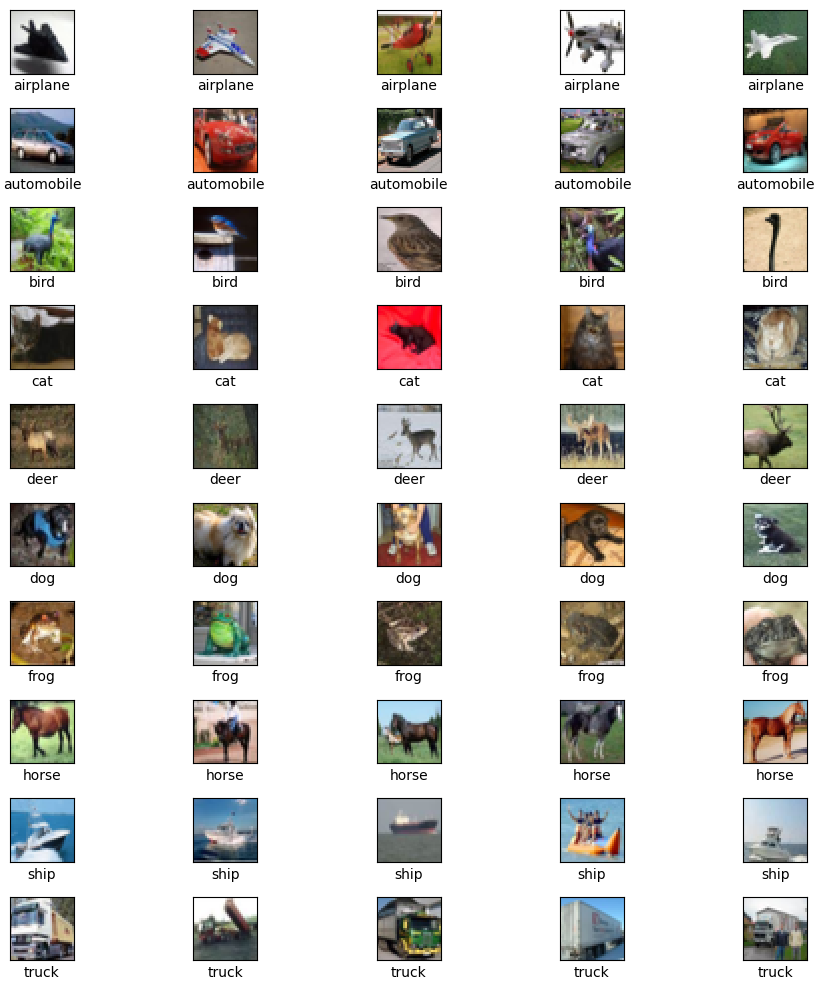

In [3]:
# --- Explore Data: แสดงภาพตัวอย่างแต่ละ class ---
plt.figure(figsize=(10, 10))
for i in range(10):
    idx = np.where(train_y == i)[0][:5]  # แสดง 5 ภาพแรกของแต่ละ class
    for j, k in enumerate(idx):
        plt.subplot(10, 5, i*5 + j + 1)
        plt.imshow(train_x[k])
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(f"{class_names[i]}")
plt.tight_layout()
plt.show()

In [5]:
# --- One-hot Encoding ---
y_train_tf = tf.keras.utils.to_categorical(train_y)
y_test_tf = tf.keras.utils.to_categorical(test_y)

# --- Normalize Images ---
train_x_normal = train_x.astype("float32") / 255
test_x_normal = test_x.astype("float32") / 255

In [6]:
# --- Build Model ---
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,162 (2.03 MB)

 Trainable params: 531,162 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# --- Compile Model ---
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- Train Model (Test case: batch_size เล็ก/ใหญ่, epochs ต่างกัน) ---
history = []
for batch_size, epochs in [(100, 5), (10000, 5)]:
    print(f"\nTraining with batch_size={batch_size}, epochs={epochs}")
    his = model.fit(
        x=train_x, y=y_train_tf,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_split=0.2,
        shuffle=True
    )
    history.append(his.history)


Training with batch_size=100, epochs=5
Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.2761 - loss: 1.9159 - val_accuracy: 0.4088 - val_loss: 1.5656
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.4874 - loss: 1.3937 - val_accuracy: 0.5131 - val_loss: 1.3526
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.5662 - loss: 1.2002 - val_accuracy: 0.5746 - val_loss: 1.2319
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.6215 - loss: 1.0625 - val_accuracy: 0.5688 - val_loss: 1.2304
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.6653 - loss: 0.9488 - val_accuracy: 0.6606 - val_loss: 0.9840

Training with batch_size=10000, epochs=5
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6974 - loss: 0.8585 - val_accuracy: 0.6537 - val_loss: 0.9928
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.6998 - loss: 0.8471 - val_accuracy: 0.6734 - val_loss: 0.9546
Epoch 3/5
4/4 ━━━━━━━━━━━━━

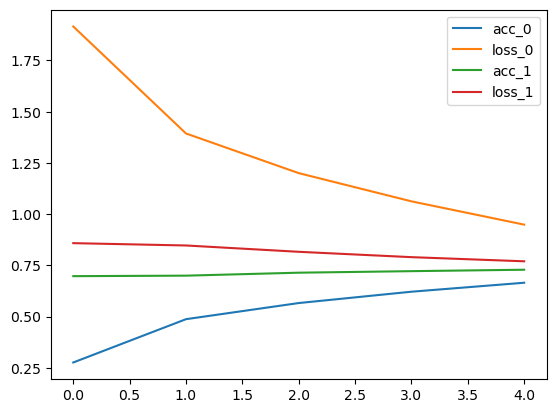

In [8]:
# --- Plot Accuracy & Loss ---
for i, his in enumerate(history):
    plt.plot(his["accuracy"], label=f"acc_{i}")
    plt.plot(his["loss"], label=f"loss_{i}")
plt.legend()
plt.show()

In [9]:
# --- Evaluate Model ---
train_loss, train_acc = model.evaluate(train_x, y_train_tf)
test_loss, test_acc = model.evaluate(test_x, y_test_tf)
print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7278 - loss: 0.7821
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6798 - loss: 0.9307
Train Accuracy: 0.7278, Test Accuracy: 0.6798


In [10]:
# --- Save & Load Model (Test case) ---
model.save("train_cifar_reference.keras")
model = tf.keras.models.load_model("train_cifar_reference.keras")


In [11]:
# --- Predict ---
y_pred_train = model.predict(train_x)
y_pred_test = model.predict(test_x)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [12]:
# --- Test case: ตรวจสอบการพยากรผิด (Train) ---
wrongIdx = []
wrongPredictList = np.zeros(len(class_names), dtype=int)
for i in range(len(train_y)):
    if train_y[i][0] != np.argmax(y_pred_train[i]):
        wrongIdx.append(i)
        wrongPredictList[train_y[i][0]] += 1
mostWrongPredictIndex = np.argmax(wrongPredictList)
mostWrongPredictCount = wrongPredictList[mostWrongPredictIndex]
mostWrongPredictName = class_names[mostWrongPredictIndex]
print(f"Total wrong prediction (Train) = {len(wrongIdx)}")
print(f"The most wrong predict data (Train) = {mostWrongPredictName} ({mostWrongPredictCount})")

Total wrong prediction (Train) = 13612
The most wrong predict data (Train) = cat (2427)


In [ ]:
# --- Test case: แสดงภาพที่พยากรผิด (Train) ---
n = len(wrongIdx)
nCols = 10
nRows = (n // nCols) + 1
plt.figure(figsize=(15, nRows * 1.5))
for idx in range(min(n, 30)):  # แสดง 30 ภาพแรกที่ผิด
    i = wrongIdx[idx]
    plt.subplot(3, 10, idx + 1)
    plt.imshow(train_x[i])
    plt.xlabel(
        f"Ans:{train_y[i][0]}|{class_names[train_y[i][0]]}\n"
        f"Pred:{np.argmax(y_pred_train[i])}|{class_names[np.argmax(y_pred_train[i])]}"
    )
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
# --- Test case: ตรวจสอบการพยากรผิด (Test) ---
wrongIdx = []
wrongPredictList = np.zeros(len(class_names), dtype=int)
for i in range(len(test_y)):
    if test_y[i][0] != np.argmax(y_pred_test[i]):
        wrongIdx.append(i)
        wrongPredictList[test_y[i][0]] += 1
mostWrongPredictIndex = np.argmax(wrongPredictList)
mostWrongPredictCount = wrongPredictList[mostWrongPredictIndex]
mostWrongPredictName = class_names[mostWrongPredictIndex]
print(f"Total wrong prediction (Test) = {len(wrongIdx)}")
print(f"The most wrong predict data (Test) = {mostWrongPredictName} ({mostWrongPredictCount})")

# --- Test case: แสดงภาพที่พยากรผิด (Test) ---
n = len(wrongIdx)
nCols = 10
nRows = (n // nCols) + 1
plt.figure(figsize=(15, nRows * 1.5))
for idx in range(min(n, 30)):  # แสดง 30 ภาพแรกที่ผิด
    i = wrongIdx[idx]
    plt.subplot(3, 10, idx + 1)
    plt.imshow(test_x[i])
    plt.xlabel(
        f"Ans:{test_y[i][0]}|{class_names[test_y[i][0]]}\n"
        f"Pred:{np.argmax(y_pred_test[i])}|{class_names[np.argmax(y_pred_test[i])]}"
    )
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

Answer: 5 | dog
Predict: 5 | dog


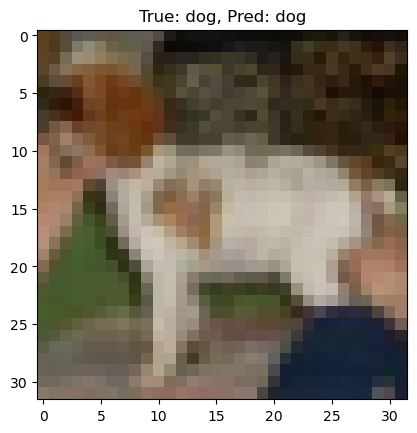

In [15]:
# --- Test case: ดูภาพเดี่ยว ๆ พร้อม label และ prediction ---
idx = 12
print(f"Answer: {test_y[idx][0]} | {class_names[test_y[idx][0]]}")
print(f"Predict: {np.argmax(y_pred_test[idx])} | {class_names[np.argmax(y_pred_test[idx])]}")
plt.imshow(test_x[idx])
plt.title(f"True: {class_names[test_y[idx][0]]}, Pred: {class_names[np.argmax(y_pred_test[idx])]}")
plt.show()

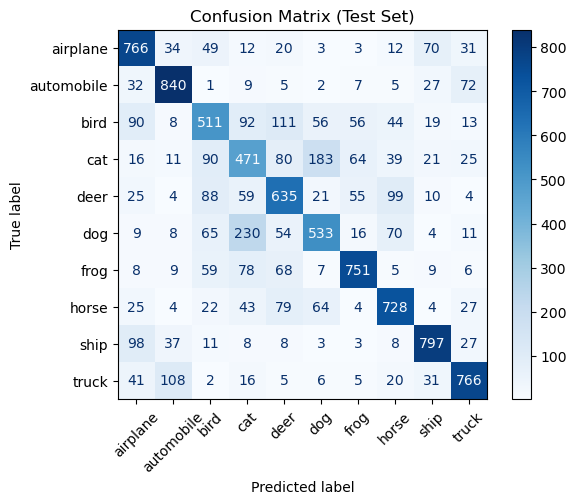

In [17]:
# --- Import เพิ่มเติม ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- สร้าง Confusion Matrix สำหรับ Test Set ---
y_true = test_y.flatten()  # แปลง shape ให้เป็น 1D
y_pred = np.argmax(y_pred_test, axis=1)  # ดึง label ที่โมเดลทำนาย

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()